In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph
import random

%matplotlib inline

In [4]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other): # other + self
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward(): 
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward  
        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-1 * other)
    
    def __rsub__(self, other): # other - self
        return other + (-1 * self)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward  
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward  
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [5]:
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad),
            shape='record'
        )
        # if this value is a result of some operation, create an op node for it
        if n._op:
            dot.node(
                name=uid + n._op,
                label=n._op
            )
            # and connect this node to the op node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [6]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'

o.backward()

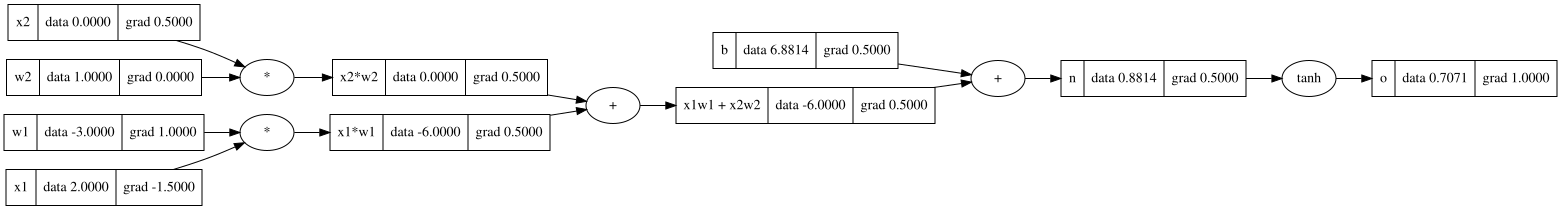

In [7]:
draw_dot(o)

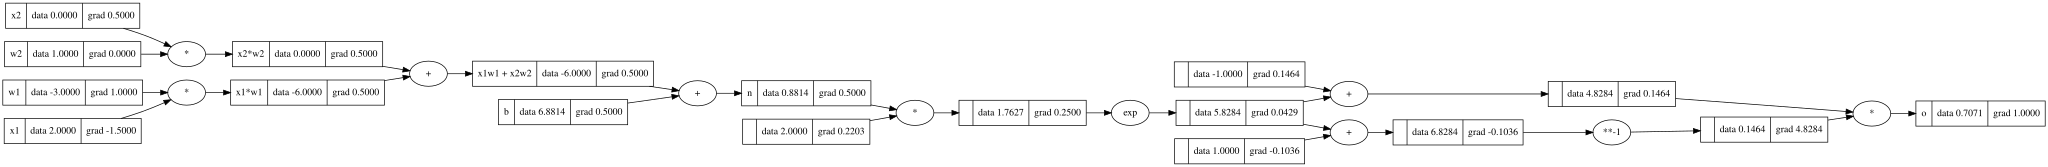

In [8]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 + b; n.label='n'
# -----
e = (2*n).exp()
o = (e-1) / (e+1)
# -----
o.label='o'

o.backward()
draw_dot(o)

In [9]:
import torch

# In this case everything is in tensor. Which are simply n-dimensional arrays of scalars.
x1 = torch.tensor([2.0]).double()   ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double()   ; x2.requires_grad = True
w1 = torch.tensor([-3.0]).double()  ; w1.requires_grad = True
w2 = torch.tensor([1.0]).double()   ; w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2.grad:', x2.grad.item())
print('w2.grad:', w2.grad.item())
print('x1.grad:', x1.grad.item())
print('w1.grad:', w1.grad.item())
print('b.grad:', b.grad.item())

0.7071066904050358
---
x2.grad: 0.5000001283844369
w2.grad: 0.0
x1.grad: -1.5000003851533106
w1.grad: 1.0000002567688737
b.grad: 0.5000001283844369


In [10]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [111]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.7048661101846861)

In [112]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # targets

In [113]:
for k in range(35):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    # backward pass
    for  p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.1 * p.grad

    print(k, loss.data)

0 6.499654171098868
1 2.262470049104362
2 1.461175553451144
3 0.7417274202092087
4 0.1562420134487344
5 0.07336326712087879
6 0.058498803191616947
7 0.049401411663902176
8 0.04290423136599011
9 0.037932389062615576
10 0.03397410203060697
11 0.030738124263085906
12 0.02804038496116578
13 0.025756499950175978
14 0.023798460863800094
15 0.022101858056411072
16 0.020618303650904578
17 0.019310670650146335
18 0.018149967027546204
19 0.01711321120109672
20 0.016181947157488843
21 0.015341182238620615
22 0.01457861212500821
23 0.013884045617456844
24 0.013248971252802732
25 0.01266622639543211
26 0.012129741529278848
27 0.011634340506953528
28 0.01117558296166207
29 0.010749638851474046
30 0.010353187747613353
31 0.00998333736019694
32 0.009637557152839059
33 0.00931362388941627
34 0.009009576688823582


In [114]:
ypred

[Value(data=0.9651459156459532),
 Value(data=-0.9586013056297209),
 Value(data=-0.9529879900793014),
 Value(data=0.9377843386250944)]